# Supervised Learning — Transaction Categorization

**Owner:** Member A (Supervised Learning)

This notebook trains a model that predicts a **Category** for each transaction from
its text description (e.g. `SQ *BLUE BOTTLE COFFEE` → `Dining`).

Pipeline: **Load → Preprocess → TF-IDF → Train & compare classifiers → Evaluate →
Handle class imbalance → Test generalization → Export model.**

> Preprocessing and data loading are imported from `src/` so the notebook and the
> production app (`app.py`) use the *exact same* logic.


In [1]:
import sys
from pathlib import Path

# Robust project-root detection (works whether run from repo root or notebooks/)
CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "src").exists() else CWD.parent
sys.path.insert(0, str(PROJECT_ROOT))

DATA_FILE = PROJECT_ROOT / "inputs" / "synthetic_chase_statement_2025.csv"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 40)
print("Project root:", PROJECT_ROOT)
print("Data file exists:", DATA_FILE.exists())


Matplotlib is building the font cache; this may take a moment.


Project root: /Users/beibei/Desktop/葡萄成熟时/graduate/NEU/26 Summer/CS6140/Project/personal-finance-insight
Data file exists: True


## Step 1 — Load & preprocess

We reuse `src/data_loader.py` and `src/preprocessing.py`. The output is a clean
DataFrame with `Date, Description, Merchant, Amount, Category`.


In [2]:
from src.data_loader import load_transactions_csv
from src.preprocessing import preprocess_transactions

raw = load_transactions_csv(DATA_FILE)
df = preprocess_transactions(raw)
print("Rows:", len(df))
df.head()


Rows: 2304


,Date,Description,Merchant,Amount,Category
0,2025-01-01,NYTIMES DIGITAL LLC,NYTIMES DIGITAL LLC,-16.44,Subscription
1,2025-01-01,H AND M LLC,H AND M LLC,-125.85,Shopping
2,2025-01-01,PAYPAL *REI OUTDOOR,PAYPAL REI OUTDOOR,-22.48,Shopping
3,2025-01-01,GRUBHUB,GRUBHUB,-10.11,Dining
4,2025-01-01,IKEA HOME,IKEA HOME,-79.52,Shopping


## Step 2 — Exploratory analysis: class distribution

Categorization is a **multi-class, imbalanced** problem. Below, `Dining` dominates
while `Housing` has only a handful of rows. Imbalance is why we later report
**macro-F1** (treats every class equally) and not just accuracy.


Category
Dining           700
Shopping         414
Grocery          354
Transport        250
Entertainment    170
Subscription     134
Transfer          95
Healthcare        60
Utilities         60
Travel            55
Housing           12
Name: count, dtype: int64


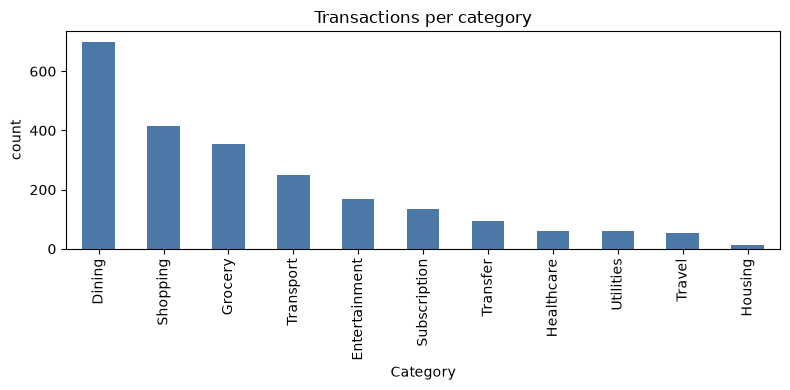

In [3]:
counts = df["Category"].value_counts()
print(counts)

fig, ax = plt.subplots(figsize=(8, 4))
counts.plot(kind="bar", ax=ax, color="#4C78A8")
ax.set_title("Transactions per category")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()


## Step 3 — Train / test split

We use the **text description** as input `X` and `Category` as label `y`.
`stratify=y` keeps each class's proportion identical in train and test — important
for imbalanced data.


In [4]:
from sklearn.model_selection import train_test_split

X = df["Description"]
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", len(X_train), " Test:", len(X_test))


Train: 1843  Test: 461


## Step 4 — TF-IDF + model comparison

**TF-IDF** converts each description into a numeric vector: words that are frequent
in a transaction but rare across the corpus (e.g. `COFFEE`, `PHARMACY`) get high
weight. `ngram_range=(1, 2)` also captures two-word phrases like `WHOLE FOODS`.

We compare three classic text classifiers taught in the course.


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

def make_pipeline(clf):
    return Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ("clf", clf),
    ])

candidates = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
}

rows = []
for name, clf in candidates.items():
    pipe = make_pipeline(clf)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rows.append({
        "model": name,
        "accuracy": round(accuracy_score(y_test, pred), 3),
        "macro_f1": round(f1_score(y_test, pred, average="macro"), 3),
    })

results = pd.DataFrame(rows).set_index("model")
results


,accuracy,macro_f1
model,,
Naive Bayes,0.978,0.968
Logistic Regression,0.978,0.964
Linear SVM,0.993,0.995


## Step 5 — Evaluate the best model

We look at the strongest model with a **per-class report** and a **confusion matrix**.
The confusion matrix shows *which* categories get confused with each other (e.g.
`Grocery` vs `Shopping` for warehouse stores like Costco).


               precision    recall  f1-score   support

       Dining       1.00      1.00      1.00       140
Entertainment       1.00      1.00      1.00        34
      Grocery       1.00      0.97      0.99        71
   Healthcare       1.00      1.00      1.00        12
      Housing       1.00      1.00      1.00         2
     Shopping       0.97      1.00      0.98        83
 Subscription       1.00      0.96      0.98        27
     Transfer       1.00      1.00      1.00        19
    Transport       1.00      1.00      1.00        50
       Travel       1.00      1.00      1.00        11
    Utilities       1.00      1.00      1.00        12

     accuracy                           0.99       461
    macro avg       1.00      0.99      1.00       461
 weighted avg       0.99      0.99      0.99       461



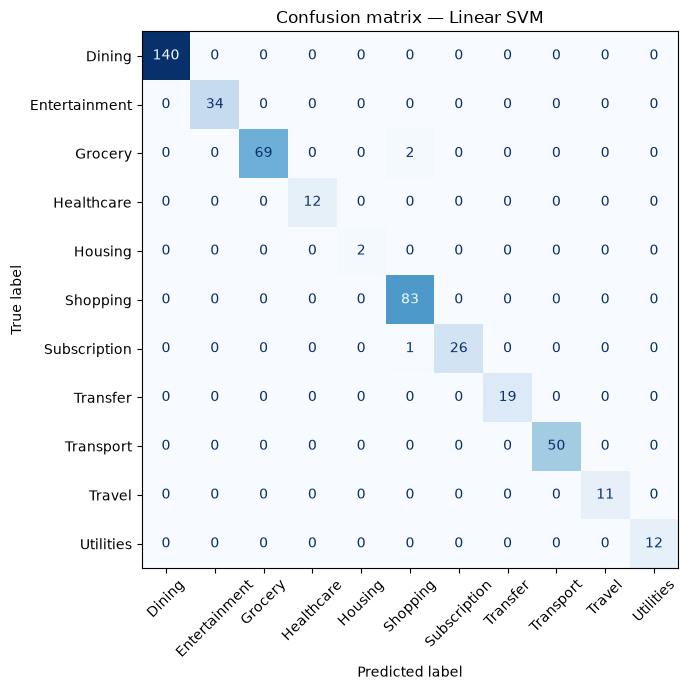

In [6]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

best = make_pipeline(LinearSVC())
best.fit(X_train, y_train)
pred = best.predict(X_test)

print(classification_report(y_test, pred))

labels = sorted(y.unique())
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, labels=labels, xticks_rotation=45,
    cmap="Blues", ax=ax, colorbar=False,
)
ax.set_title("Confusion matrix — Linear SVM")
plt.tight_layout()
plt.show()


## Step 6 — Handling class imbalance

Rare classes (`Housing`, `Travel`) have few examples, so the model sees them less.
`class_weight="balanced"` tells the model to *weight rare classes more heavily*.
We compare macro-F1 before vs after — macro-F1 is the right metric because it
averages per-class scores equally, so gains on rare classes show up.


In [7]:
def macro_f1_of(clf):
    p = make_pipeline(clf)
    p.fit(X_train, y_train)
    return round(f1_score(y_test, p.predict(X_test), average="macro"), 3)

comparison = pd.DataFrame({
    "default": {
        "Logistic Regression": macro_f1_of(LogisticRegression(max_iter=1000)),
        "Linear SVM": macro_f1_of(LinearSVC()),
    },
    "class_weight=balanced": {
        "Logistic Regression": macro_f1_of(LogisticRegression(max_iter=1000, class_weight="balanced")),
        "Linear SVM": macro_f1_of(LinearSVC(class_weight="balanced")),
    },
})
comparison


,default,class_weight=balanced
Logistic Regression,0.964,0.993
Linear SVM,0.995,0.995


## Step 7 — Generalization: can it categorize an *unseen* merchant?

A random split lets the *same* merchant appear in train and test, so the model can
"memorize". The real-world test is a **merchant-grouped split**: every merchant in
the test set is one the model has **never seen**. Success here means the model truly
learned from shared tokens (`COFFEE`, `MARKET`, ...) rather than memorizing brands.


In [8]:
from sklearn.model_selection import GroupShuffleSplit

groups = df["Merchant"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
tr_idx, te_idx = next(gss.split(X, y, groups))

assert set(groups.iloc[tr_idx]).isdisjoint(set(groups.iloc[te_idx]))  # no overlap

pipe = make_pipeline(LinearSVC(class_weight="balanced"))
pipe.fit(X.iloc[tr_idx], y.iloc[tr_idx])
pred_g = pipe.predict(X.iloc[te_idx])

print("Unseen-merchant accuracy :", round(accuracy_score(y.iloc[te_idx], pred_g), 3))
print("Unseen-merchant macro-F1 :", round(f1_score(y.iloc[te_idx], pred_g, average="macro"), 3))
print(f"\nTrain merchants: {groups.iloc[tr_idx].nunique()} | "
      f"Test merchants: {groups.iloc[te_idx].nunique()} | overlap: 0")


Unseen-merchant accuracy : 0.771
Unseen-merchant macro-F1 : 0.851

Train merchants: 840 | Test merchants: 360 | overlap: 0


## Step 8 — Train final model on all data & export

For the production model we refit on the **full** dataset (train + test) so it uses
every available example, then save it as `models/category_model.pkl`. The app loads
this file and never retrains.


In [9]:
import joblib
import json

final_model = make_pipeline(LinearSVC(class_weight="balanced"))
final_model.fit(X, y)

model_path = MODELS_DIR / "category_model.pkl"
joblib.dump(final_model, model_path)

# Record the categories the model can output (useful for the app / downstream).
meta = {
    "categories": sorted(y.unique().tolist()),
    "n_training_rows": int(len(df)),
    "vectorizer": "tfidf(1,2), min_df=2",
    "classifier": "LinearSVC(class_weight=balanced)",
}
with open(MODELS_DIR / "category_model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved:", model_path)
print("Sanity check:", final_model.predict(["SQ *PHILZ COFFEE PALO ALTO CA",
                                            "CHEVRON GAS #4471",
                                            "NETFLIX.COM"]))


Saved: /Users/beibei/Desktop/葡萄成熟时/graduate/NEU/26 Summer/CS6140/Project/personal-finance-insight/models/category_model.pkl
Sanity check: ['Dining' 'Transport' 'Subscription']
